Baseline RF Accuracy: 0.9994

Tuning Random Forest (this may take a minute)...

--- Optimized Random Forest Results ---
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True}
Tuned Accuracy: 0.9981

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       477

    accuracy                           1.00      1594
   macro avg       1.00      1.00      1.00      1594
weighted avg       1.00      1.00      1.00      1594



/tmp/ipython-input-3804086285.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


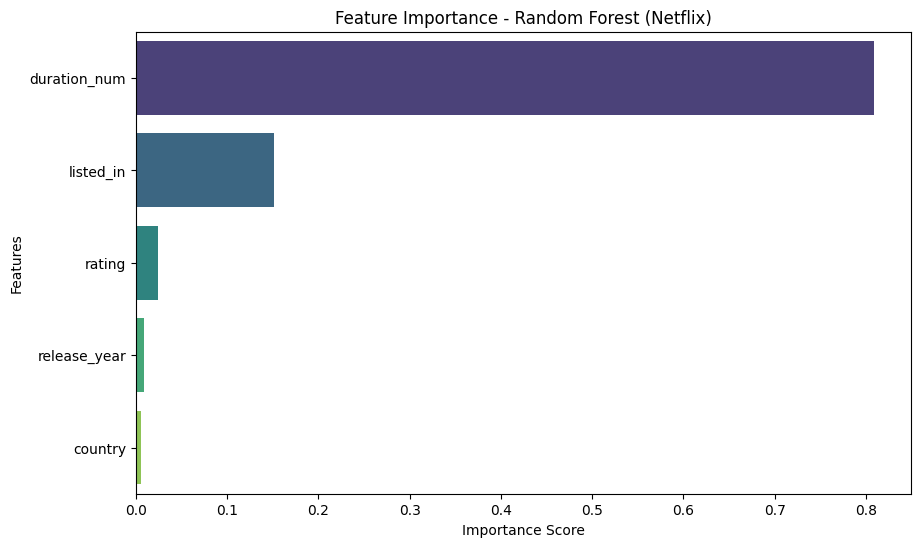

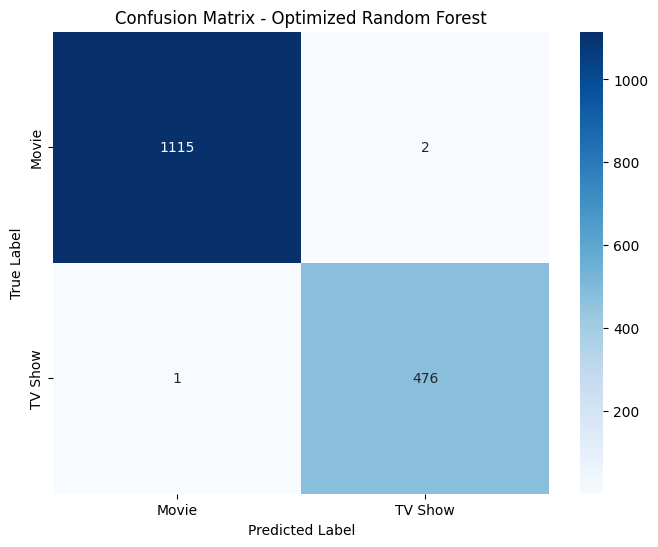

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

# =============================
# DATA CLEANING (Netflix Version)
# =============================
df = df[['type','release_year','rating','country','listed_in','duration']].copy()

# Convert duration text → numeric
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df.drop('duration', axis=1, inplace=True)

df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Label Encoding (same logic as adult.csv code)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# =============================
# FEATURES + TARGET
# =============================
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# BASELINE RANDOM FOREST
# =============================
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

print(f"Baseline RF Accuracy: {accuracy_score(y_test, rf_base.predict(X_test)):.4f}")

# =============================
# RANDOMIZED SEARCH (TUNING)
# =============================
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

print("\nTuning Random Forest (this may take a minute)...")

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)

print("\n--- Optimized Random Forest Results ---")
print(f"Best Parameters: {rf_random.best_params_}")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =============================
# FEATURE IMPORTANCE GRAPH
# =============================
importances = best_rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15),   # cleaner graph
    palette='viridis'
)

plt.title('Feature Importance - Random Forest (Netflix)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# =============================
# CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Movie','TV Show'],
    yticklabels=['Movie','TV Show']
)

plt.title('Confusion Matrix - Optimized Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
